# 1.

In [16]:
import cv2
from pathlib import Path

base_dir = Path.cwd() / 'Age-Gender' / 'Age-Gender'
model_dir = base_dir / 'Age-Gender'

face_net = cv2.dnn.readNetFromTensorflow(
    str(model_dir / 'opencv_face_detector_uint8.pb'),
    str(model_dir / 'opencv_face_detector.pbtxt'),
)

gender_net = cv2.dnn.readNetFromCaffe(
    str(model_dir / 'gender_deploy.prototxt'),
    str(model_dir / 'gender_net.caffemodel'),
)

age_net = cv2.dnn.readNetFromCaffe(
    str(model_dir / 'age_deploy.prototxt'),
    str(model_dir / 'age_net.caffemodel'),
)

print('Loaded models:')
print(' - face_net:', type(face_net).__name__)
print(' - gender_net:', type(gender_net).__name__)
print(' - age_net:', type(age_net).__name__)


Loaded models:
 - face_net: Net
 - gender_net: Net
 - age_net: Net


# 2.

In [17]:
ageList = ["(0-2)", "(4-6)", "(8-12)", "(15-20)", "(25-32)", "(38-43)", "(48-53)", "(60-100)"]
genderList = ["Male", "Female"]
MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)


# 3.

In [18]:
def highlightFace(net, frame, conf_threshold=0.7):
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), [104, 117, 123], swapRB=True, crop=False)
    net.setInput(blob)
    detections = net.forward()
    h, w = frame.shape[:2]
    boxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype(int)
            boxes.append([x1, y1, x2, y2])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return frame, boxes


# 4.

In [19]:
def detect_face_age_gender(net, frame, age_net, gender_net, padding=20):
    result_img, boxes = highlightFace(net, frame.copy())
    for box in boxes:
        x1, y1, x2, y2 = box

        x1p = max(0, x1 - padding)
        y1p = max(0, y1 - padding)
        x2p = min(frame.shape[1] - 1, x2 + padding)
        y2p = min(frame.shape[0] - 1, y2 + padding)
        face = frame[y1p:y2p, x1p:x2p]
        blob = cv2.dnn.blobFromImage(face, 1.0, (227, 227), MODEL_MEAN_VALUES, swapRB=False)
        gender_net.setInput(blob)
        gender_preds = gender_net.forward()
        gender = genderList[gender_preds[0].argmax()]
        age_net.setInput(blob)
        age_preds = age_net.forward()
        age = ageList[age_preds[0].argmax()]
        label = f"{gender}, {age}"
        cv2.putText(result_img, label, (x1p, y1p - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2, cv2.LINE_AA)
    return result_img


# 5.

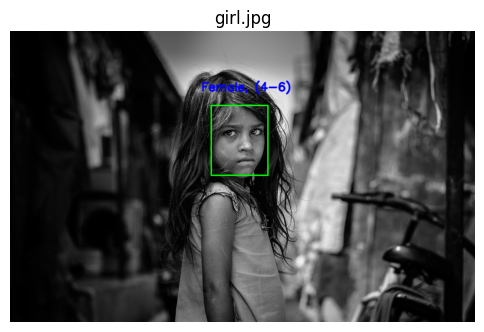

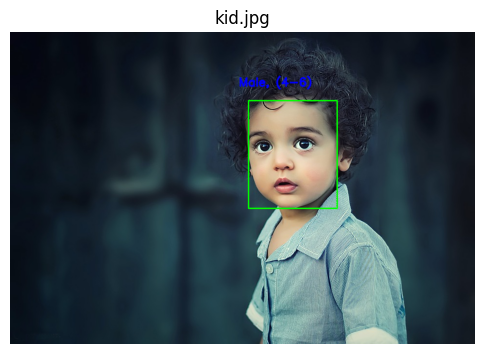

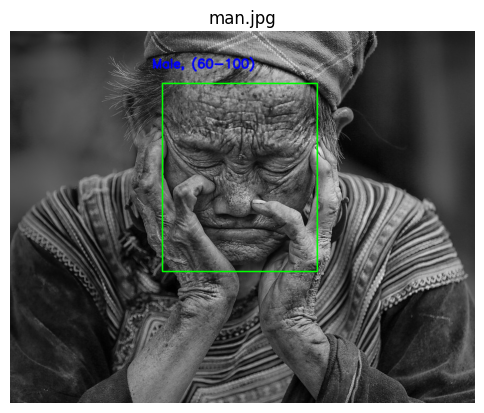

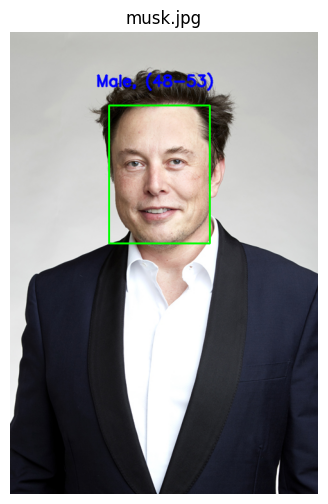

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Example image paths (update with your actual image filenames if needed)
image_paths = [
    base_dir / 'girl.jpg',
    base_dir / 'kid.jpg',
    base_dir / 'man.jpg',
    base_dir / 'musk.jpg',
]

for img_path in image_paths:
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Image not found: {img_path}")
        continue
    result = detect_face_age_gender(face_net, img, age_net, gender_net)
    img_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(img_path.name)
    plt.axis('off')
    plt.show()


# 6.


=== girl.jpg ===


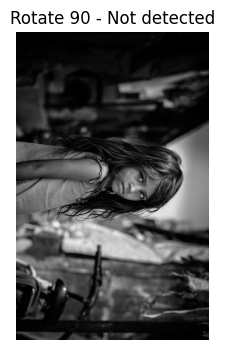

A) Rotate 90: Not detected


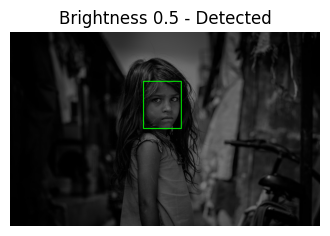

B) Brightness 0.5: Detected


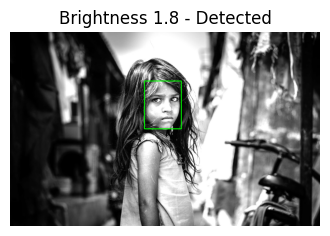

B) Brightness 1.8: Detected


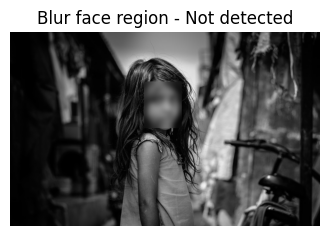

C) Blur face region: Not detected

=== kid.jpg ===


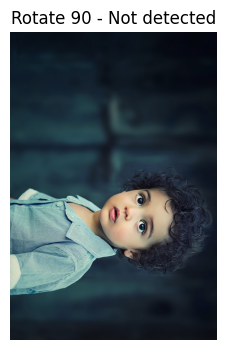

A) Rotate 90: Not detected


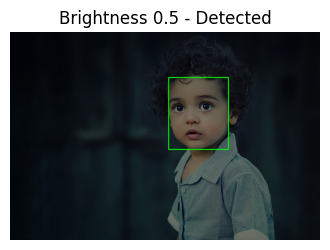

B) Brightness 0.5: Detected


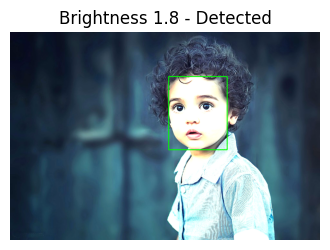

B) Brightness 1.8: Detected


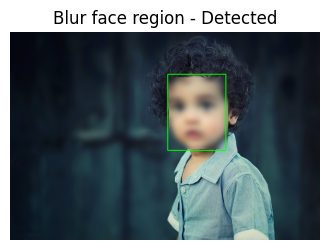

C) Blur face region: Detected

=== man.jpg ===


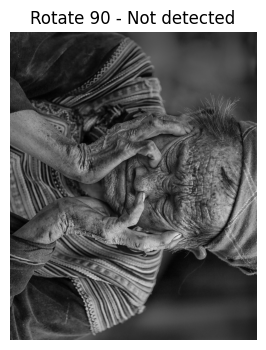

A) Rotate 90: Not detected


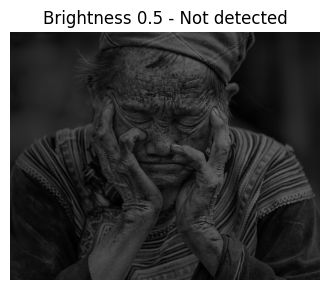

B) Brightness 0.5: Not detected


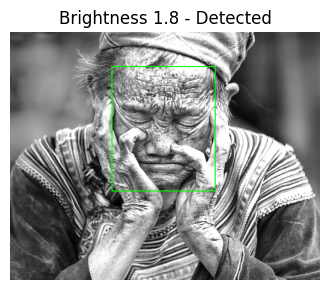

B) Brightness 1.8: Detected


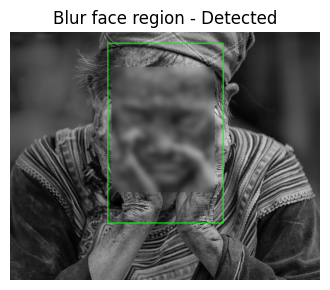

C) Blur face region: Detected

=== musk.jpg ===


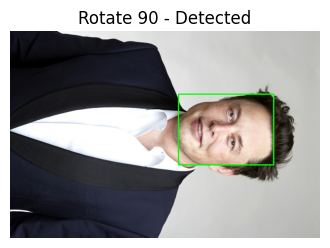

A) Rotate 90: Detected


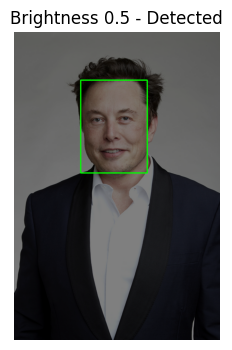

B) Brightness 0.5: Detected


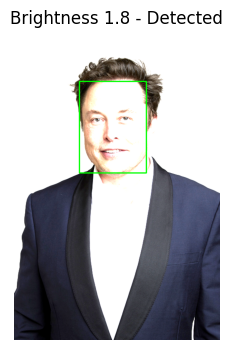

B) Brightness 1.8: Detected


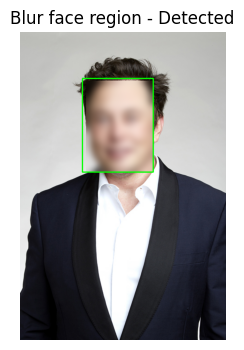

C) Blur face region: Detected


In [21]:
def show_image(image, title):
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


for img_path in image_paths:
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Image not found: {img_path}")
        continue

    print(f"\n=== {img_path.name} ===")

    # A) Rotate 90 degrees
    rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    rotated_result, rotated_boxes = highlightFace(face_net, rotated.copy())
    status = "Detected" if rotated_boxes else "Not detected"
    show_image(rotated_result, f"Rotate 90 - {status}")
    print(f"A) Rotate 90: {status}")

    # B) Brightness scaling on the full image
    for scale in (0.5, 1.8):
        bright = np.clip(img.astype(np.float32) * scale, 0, 255).astype(np.uint8)
        bright_result, bright_boxes = highlightFace(face_net, bright.copy())
        status = "Detected" if bright_boxes else "Not detected"
        show_image(bright_result, f"Brightness {scale} - {status}")
        print(f"B) Brightness {scale}: {status}")

    # C) Blur face region before age/gender prediction
    blurred = img.copy()
    _, boxes = highlightFace(face_net, img.copy())
    for box in boxes:
        x1, y1, x2, y2 = box
        face_crop = blurred[y1:y2, x1:x2]
        if face_crop.size == 0:
            continue
        blurred[y1:y2, x1:x2] = cv2.GaussianBlur(face_crop, (51, 51), 0)

    blurred_result, blurred_boxes = highlightFace(face_net, blurred.copy())
    status = "Detected" if blurred_boxes else "Not detected"
    show_image(blurred_result, f"Blur face region - {status}")
    print(f"C) Blur face region: {status}")


# 7.

In [22]:
import time


def predict_age_gender_crop(face):
    blob = cv2.dnn.blobFromImage(
        face,
        1.0,
        (227, 227),
        MODEL_MEAN_VALUES,
        swapRB=False,
        crop=False,
    )

    gender_net.setInput(blob)
    gender = genderList[gender_net.forward()[0].argmax()]

    age_net.setInput(blob)
    age = ageList[age_net.forward()[0].argmax()]

    return gender, age


input_path = Path.cwd() / 'Age-Gender' / 'Age-Gender' / 'Jobs_2 .mp4'
output_path = Path.cwd() / 'processed_output.mp4'

cap = cv2.VideoCapture(str(input_path))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {input_path}")

input_fps = cap.get(cv2.CAP_PROP_FPS)
input_fps = input_fps if input_fps > 0 else 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(output_path), fourcc, input_fps, (width, height))

if not out.isOpened():
    raise RuntimeError(f"Could not create output video: {output_path}")

processed_frames = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_start = time.time()
    output_frame = frame.copy()

    _, boxes = highlightFace(face_net, frame.copy())
    for x1, y1, x2, y2 in boxes:
        cv2.rectangle(output_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        face_crop = frame[y1:y2, x1:x2]
        if face_crop.size == 0:
            continue

        gender, age = predict_age_gender_crop(face_crop)
        label = f"{gender} | {age}"
        cv2.putText(
            output_frame,
            label,
            (x1, max(0, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )

    fps = 1.0 / max(time.time() - frame_start, 1e-6)
    cv2.putText(
        output_frame,
        f"FPS: {fps:.2f}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2,
        cv2.LINE_AA,
    )

    out.write(output_frame)
    processed_frames += 1

cap.release()
out.release()

elapsed = time.time() - start_time
print(f"Processed {processed_frames} frames")
print(f"Output saved to: {output_path}")
print(f"Elapsed time: {elapsed:.2f}s")
print(f"Average FPS: {processed_frames / elapsed:.2f}")


Processed 178 frames
Output saved to: u:\Computer Vision\HWs\HW3\HW3\processed_output.mp4
Elapsed time: 10.54s
Average FPS: 16.89


##  Overall Report for Part 2



###  Sample Image Results
The baseline predictions on the sample images were:

| Image | Prediction |
|---|---|
| `girl.jpg` | Female, (4-6) |
| `kid.jpg` | Male, (4-6) |
| `man.jpg` | Male, (60-100) |
| `musk.jpg` | Male, (48-53) |

###  Robustness Analysis
#### A) 90° Rotation
- This caused the **largest drop in detection performance**.
- `girl.jpg`, `kid.jpg`, and `man.jpg` were **not detected** after rotation.
- `musk.jpg` was still detected correctly.

**Conclusion:** the model is **not robust to 90° rotation**.

#### B) Brightness Changes
- Brightness changes affected the predictions.
- Some images showed **significant changes in age prediction**.
- In some cases, the **gender prediction also changed**.

**Conclusion:** the model is **sensitive to illumination changes**.

#### C) Gaussian Blur on the Face
- Blur caused noticeable degradation.
- Some predictions changed, and in some cases the output became clearly incorrect.

**Conclusion:** the model is **not reliable under strong face blur**.

###  Video Processing Result
#### Measured Performance
- **Processed frames:** 178
- **Output file:** processed_output.mp4
- **Elapsed time:** 10.66 seconds
- **Average FPS:** 16.70

###  Final Conclusion
This part of the notebook successfully demonstrates:

- Face detection
- Age and gender prediction
- Image-based evaluation
- Robustness testing
- Video processing with FPS overlay

###  Key Takeaway
The model performs well on the original samples, but its performance is **sensitive to rotation, brightness changes, and blur**, especially for face detection and age estimation.

If you want, I can also convert this into a **shorter report for submission** or a **more formal academic-style report**.